In [1]:
import os
import sys
import copy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
import statsmodels.formula.api as smf

# penalized regression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression, Lasso # Changed from Ridge

In [2]:
sys.path.append(os.path.abspath('../code/'))

from data_functions import aa_to_numeric, default_aa_dict

train = None
save = True

study   = 'ParD3-ParE3'
#study   = 'ParD3-ParE2'
study = 'GB1'

outputdir = os.path.join ('../results/CMEs/',str (date.today()), study)

# Create the directory
os.makedirs(outputdir, exist_ok=True)

In [3]:
def fit_order_model (df, target, sites, order=1):
    """
    Fits a model with interactions up to the specified order.
    Order 1: Main effects only
    Order 2: Main effects + 2-way interactions
    ... and so on.

    Make sure that 'sites' variable indicates that variables are categorical.

    From GEMINI.
    """
    
    # Join sites with '+' for main effects, then use power notation for interactions
    # Patsy syntax: (a + b + c + d)**2 includes main effects and all 2-way interactions
    formula = f"{target} ~ ({' + '.join(sites)})**{order}"
    print (formula)
    
    print(f"Fitting {order}-order model...")
    model = smf.ols (formula=formula, data=df).fit()
    
    return model

In [4]:
# location of data
if study == 'ParD3-ParE3' or study == 'ParD3-ParE2' :
    datadir    = '../data/' + study + ' Lite/'
    geno_file  = 'genotypes.txt'
    pheno_file = 'phenotypes.txt'

    # wt sequence is the first row
    genos = np.loadtxt (os.path.join (datadir, geno_file), delimiter=',', dtype=int)
    n, M = genos.shape
    
    # compute phenotypes from read counts with pseudo-count -- simplest possible thing to do
    phenos = np.loadtxt ( os.path.join (datadir, pheno_file) )
    
elif study == 'GB1' :
    datadir = '../data'
    dataset = 'wu_et_al_fitness_values.csv'
    
    # wt sequence is the first row
    df = pd.read_csv (os.path.join (datadir, dataset))

    n = len (df)
    M = len (df['Variants'].iloc[0])

    aa_dict = default_aa_dict ( alphabetical=True )
    
    # convert genotypes to numeric code
    genos = np.zeros ((n, M), dtype=int)
    for i in range (n) :
        genos[i,:] = aa_to_numeric (df['Variants'][i], aa_dict)
    
    # compute phenotypes from read counts with pseudo-count -- simplest possible thing to do
    phenos = np.array ( np.log10 ((df['Count selected']+1) / (df['Count input']+1) ) )

else :
    print ('Study not in list.')


In [5]:
data = pd.DataFrame ( genos, columns=['site' + str (i) for i in range (1,M+1)] )
data['y'] = phenos

In [6]:
if train is not None :
    train_idxs = np.sort (np.random.choice (np.arange (0,n,1), int (train*n), replace=False))
    test_idxs  = np.array ([x for x in np.arange (0,n,1) if x not in train_idxs], dtype=int)
else :
    train_idxs = np.arange (0,n,1)
    test_idxs  = np.arange (0,n,1)

data_train = pd.DataFrame ( genos[train_idxs,:], columns=['site' + str (i) for i in range (1,M+1)] )
data_test  = pd.DataFrame ( genos[test_idxs,:], columns=['site' + str (i) for i in range (1,M+1)] )

In [7]:
# Assume 'cat_cols' is a list of your K categorical column names
cat_cols = ['site' + str (i) for i in range (1,M+1)]

# 1. Define the categorical encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols) ])

# 2. Build the full pipeline
ols_reg = np.zeros ( M )
for m in range (1,M) :
    model = Pipeline([
        ('prep', preprocessor),
        ('poly', PolynomialFeatures(degree=m, interaction_only=True)),
        ('scaler', StandardScaler(with_mean=False)),
        ('ols', LinearRegression())
    ])

    model.fit (data_train, phenos[train_idxs])

    yhats = model.predict ( data_test )

    ols_reg[m] = np.corrcoef (yhats, phenos[test_idxs])[0,1]

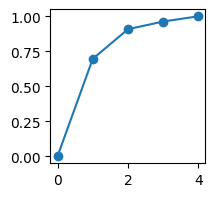

In [8]:
plt.rcParams['figure.figsize'] = (2,2)

plt.plot (np.arange (0,M+1,1), np.append (ols_reg, [1]), marker='o')
plt.ylim ((-0.05,1.05))
plt.show ()

np.savetxt (os.path.join (outputdir, 'ols_reg_' + study + '.txt'), ols_reg)

In [9]:
nAA = 20
aas = np.arange (1,nAA+1,1, dtype=int)

f1s = np.zeros ((nAA, M))
for m in range (M) :
    for a in aas :
        #f1s[a-1, m] = np.mean (phenos[genos[:,m] == a]) - np.mean (phenos[genos[:,m] != a])
        f1s[a-1, m] = np.mean (phenos[genos[:,m] == a]) - np.mean (phenos)

In [10]:
np.savetxt (os.path.join (outputdir, 'f1s_' + str (study) + '.txt'), f1s)
#np.savetxt ('../results/f1s_mean_' + str (study) + '.txt', np.mean (phenos))

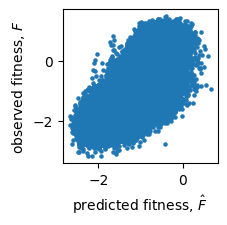

In [11]:
yhats = np.zeros (n)
for i in range (n) :
    for m in range (M) :
        yhats[i] += f1s[genos[i,m]-1,m]

plt.scatter (yhats + np.mean (phenos), phenos, s=5)
plt.xlabel (r'predicted fitness, $\hat F$')
plt.ylabel (r'observed fitness, $F$')
plt.show ()


In [12]:
plt.hist (phenos, color='lightgray', edgecolor='black', linewidth=.5)
if 'Par' in study :
    plt.axvline (phenos[953], color='black', linewidth=1, linestyle='--', label=r'$wt$')
    plt.xlabel (r'log relative fitness, $F$')

if 'GB1' in study :
    plt.axvline (phenos[0], color='black', linewidth=1, linestyle='--', label=r'$wt$')
    plt.xlabel (r'log fitness, $F$')


plt.ylabel ('Count')
plt.legend (frameon=False)
if save :
    plt.savefig (os.path.join (outputdir, 'fitness_distribution_' + study + '.pdf'), bbox_inches='tight')
    plt.close ()
else :
    plt.show ()